In [1]:
import pandas as pd
import tempfile
from tokenizers import BertWordPieceTokenizer
from transformers import BertTokenizerFast
from transformers import BertConfig
from transformers import BertForMaskedLM
from datasets import load_dataset
from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments
from transformers import BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder
from datasets import load_dataset
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import torch
import tqdm
from sklearn import model_selection
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
from torch import nn


Загрузка данных

In [ ]:
# model_path = "../../data/interim/bert"
model_path = "/kaggle/input/models/mcchainiy/bert/transformers/default/1/bert"
bert = model = BertForSequenceClassification.from_pretrained(model_path, num_labels=4)
tokenizer = BertTokenizerFast.from_pretrained(model_path)

Loading weights:   0%|          | 0/69 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /kaggle/input/models/mcchainiy/bert/transformers/default/1/bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstre

In [ ]:
# train_path = "../../data/interim/train.csv"
# test_path = "../../data/interim/test.csv"
train_path = "/kaggle/input/datasets/mcchainiy/train-csv/train.csv"
test_path = "/kaggle/input/datasets/mcchainiy/true-test-csv/test.csv"

In [4]:
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

In [5]:
train_dataset = load_dataset("csv", data_files=train_path)
train_dataset = train_dataset.class_encode_column("label")

test_dataset = load_dataset("csv", data_files=test_path)
test_dataset = test_dataset.class_encode_column("label")

Generating train split: 0 examples [00:00, ? examples/s]

Casting to class labels:   0%|          | 0/198624 [00:00<?, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Casting to class labels:   0%|          | 0/49657 [00:00<?, ? examples/s]

In [6]:
train_dataset = train_dataset["train"].train_test_split(test_size=0.2, stratify_by_column='label', seed=42)

In [7]:
def tokenize_classification(examples):
    return tokenizer(
        examples["comment"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_classification, batched=True)
train_dataset = train_dataset.rename_column("label", "labels")
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/158899 [00:00<?, ? examples/s]

Map:   0%|          | 0/39725 [00:00<?, ? examples/s]

In [8]:
val_dataset = train_dataset["test"]
train_dataset = train_dataset["train"]

Дообучение берта на классификацию

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    f1_macro = f1_score(labels, predictions, average='macro')
    
    return {
        'f1_macro': f1_macro
    }

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        weights = torch.tensor([4.0, 1.0, 20.0, 8.0], device=logits.device) 
        
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [10]:
import warnings

warnings.filterwarnings("ignore", message="Was asked to gather along dimension 0, but all input tensors were scalars")

In [11]:
training_args = TrainingArguments(
    output_dir="./bert_output2",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    save_total_limit=3,
    learning_rate=5e-5,
    eval_strategy="steps",
    eval_steps=500,
    logging_steps=100,
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Step,Training Loss,Validation Loss,F1 Macro
500,1.082702,1.035042,0.417342
1000,0.868544,0.825310,0.520206
1500,0.732178,0.674904,0.624113
2000,0.613633,0.569159,0.664234
2500,0.560284,0.522730,0.751475
3000,0.423020,0.459659,0.759393
3500,0.406823,0.430972,0.785451
4000,0.369855,0.407138,0.784126
4500,0.377382,0.389789,0.797603
5000,0.376909,0.419718,0.824415


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias'].
There were unexpected keys in the checkp

TrainOutput(global_step=24830, training_loss=0.2515520632002942, metrics={'train_runtime': 1576.1807, 'train_samples_per_second': 1008.127, 'train_steps_per_second': 15.753, 'total_flos': 2655161713551360.0, 'train_loss': 0.2515520632002942, 'epoch': 10.0})

In [ ]:
trainer.save_model("../../data/interim/bert-clf3")
tokenizer.save_pretrained("../../data/interim/bert-clf3")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert-clf3/tokenizer_config.json', 'bert-clf3/tokenizer.json')

In [13]:
import shutil
shutil.make_archive('bert-clf3', 'zip', './bert-clf3')

'/kaggle/working/bert-clf3.zip'

Применение модели

In [6]:
model_path = "./bert-clf3"
model = BertForSequenceClassification.from_pretrained(model_path, num_labels=4)
tokenizer = BertTokenizerFast.from_pretrained(model_path)

In [7]:
label_map = {
    0: "INSULT",
    1: "NORMAL",
    2: "OBSCENITY",
    3: "THREAT"
}
def bert_predict_series(texts, batch_size=32):
    model.eval()
    
    all_preds = []
    
    texts = texts.tolist()
    
    for i in tqdm.tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
    
    return [label_map[p] for p in all_preds]

In [8]:
test_path = '../../data/interim/test.csv'
df_test = pd.read_csv(test_path)
X = df_test['comment']
y = df_test['label']

In [11]:
def print_multiclass_metrics(y_test, y_pred, model_name='LR', df=df_test):
    print("f1 macro score:", f1_score(y_test, y_pred, average='macro'))
    print("f1 weighted score:", f1_score(y_test, y_pred, average='weighted'))
    print(f"{model_name} accurcay:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['INSULT', 'NORMAL', 'THREAT', 'OBSCENITY']))


    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=df['label'].unique(), yticklabels=df['label'].unique())

In [12]:
y_pred = bert_predict_series(X)

100%|██████████| 1552/1552 [01:28<00:00, 17.59it/s]


f1 macro score: 0.8371421034643916
f1 weighted score: 0.9447491199534293
LR accurcay: 0.9449020279114727
              precision    recall  f1-score   support

      INSULT       0.81      0.78      0.80      5713
      NORMAL       0.98      0.98      0.98     40736
      THREAT       0.74      0.76      0.75       852
   OBSCENITY       0.80      0.85      0.82      2356

    accuracy                           0.94     49657
   macro avg       0.83      0.84      0.84     49657
weighted avg       0.94      0.94      0.94     49657



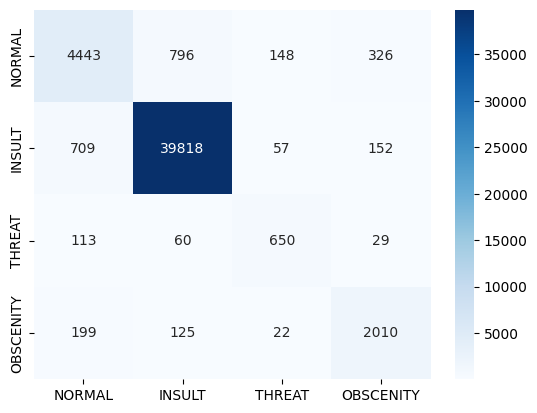

In [13]:
print_multiclass_metrics(y, y_pred)